In [2]:
# EDA: Load HAR Inertial Signals for TCN/1D-CNN Pipeline
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.append(str(Path('..') / 'src'))
import data_loader

# Load inertial data (raw sensor signals)
X_train, X_test, y_train, y_test, subj_train, subj_test, activity_labels = data_loader.load_har_inertial_data()

print(f"Train shape: {X_train.shape}")  # (n_windows, 128, 9)
print(f"Test shape: {X_test.shape}")
print(f"Channels: {data_loader.CHANNEL_NAMES}")
print(f"Activity labels: {activity_labels}")

# Quick preview of first window
print(f"\nFirst training window shape: {X_train[0].shape}")
print(f"First window activity: {activity_labels[y_train[0]]}")
print(f"First window subject: {subj_train[0]}")

Train shape: (7352, 128, 9)
Test shape: (2947, 128, 9)
Channels: ['total_acc_x', 'total_acc_y', 'total_acc_z', 'body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x', 'body_gyro_y', 'body_gyro_z']
Activity labels: {1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS', 4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}

First training window shape: (128, 9)
First window activity: STANDING
First window subject: 1


In [3]:
# Dataset overview and activity distribution
print("=== Dataset Overview ===")
print(f"Train windows: {X_train.shape[0]}")
print(f"Test windows: {X_test.shape[0]}")
print(f"Timesteps per window: {X_train.shape[1]}")
print(f"Sensor channels: {X_train.shape[2]}")

print(f"\nSubjects in train: {len(np.unique(subj_train))}")
print(f"Subjects in test: {len(np.unique(subj_test))}")

# Activity distribution
train_activities = [activity_labels[label] for label in y_train]
test_activities = [activity_labels[label] for label in y_test]

print("\n=== Activity Distribution ===")
train_counts = pd.Series(train_activities).value_counts()
test_counts = pd.Series(test_activities).value_counts()

print("Train:")
print(train_counts)
print("\nTest:")
print(test_counts)

# Data type and range info
print(f"\n=== Data Characteristics ===")
print(f"Data type: {X_train.dtype}")
print(f"Train data range: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"Test data range: [{X_test.min():.3f}, {X_test.max():.3f}]")

=== Dataset Overview ===
Train windows: 7352
Test windows: 2947
Timesteps per window: 128
Sensor channels: 9

Subjects in train: 21
Subjects in test: 9

=== Activity Distribution ===
Train:
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

Test:
LAYING                537
STANDING              532
WALKING               496
SITTING               491
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
Name: count, dtype: int64

=== Data Characteristics ===
Data type: float32
Train data range: [-5.974, 5.746]
Test data range: [-3.432, 3.468]


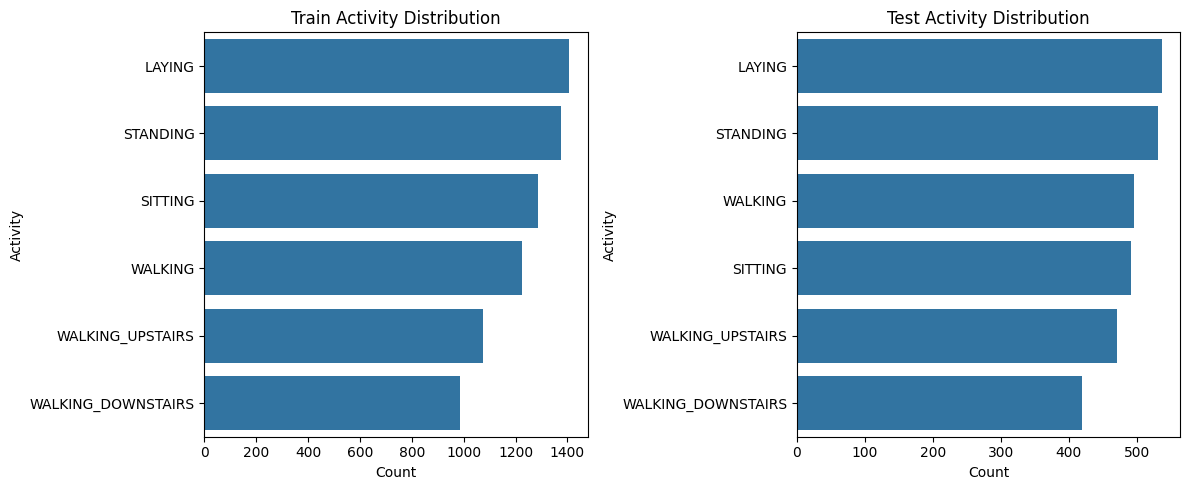

In [ ]:
# Plot activity distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train distribution
train_df = pd.DataFrame({'Activity': [activity_labels[y] for y in y_train]})
sns.countplot(y='Activity', data=train_df, ax=axes[0], order=train_df['Activity'].value_counts().index)
axes[0].set_title('Train Activity Distribution')
axes[0].set_xlabel('Count')

# Test distribution  
test_df = pd.DataFrame({'Activity': [activity_labels[y] for y in y_test]})
sns.countplot(y='Activity', data=test_df, ax=axes[1], order=test_df['Activity'].value_counts().index)
axes[1].set_title('Test Activity Distribution')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

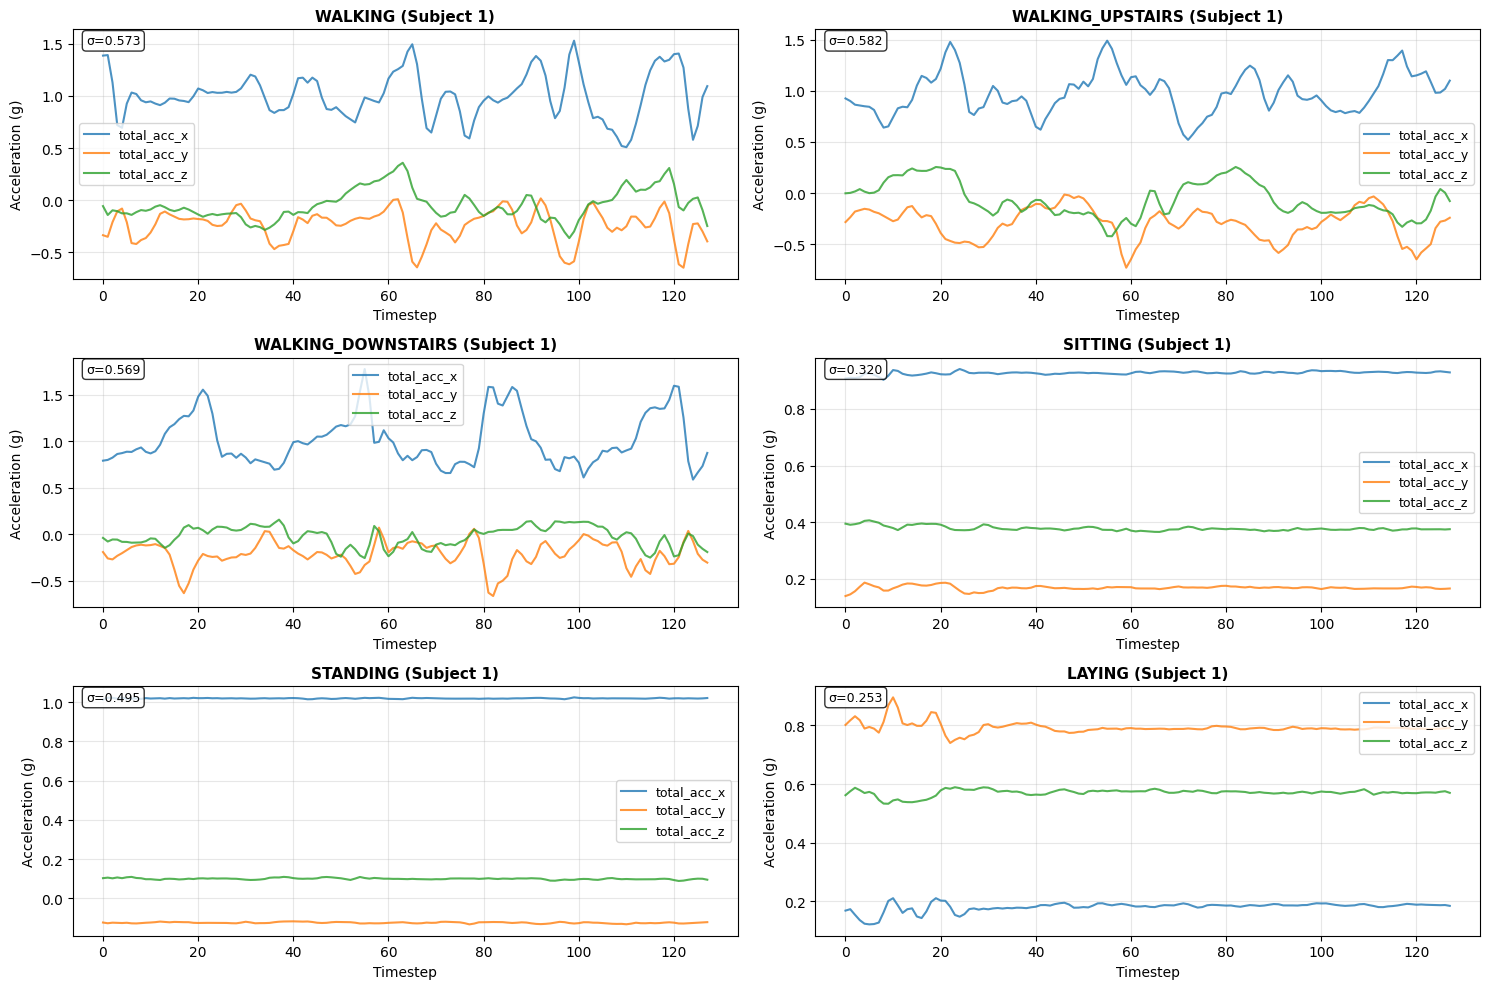

In [ ]:
# Visualize sample time series for different activities
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

# Plot one example from each activity
for i, (activity_id, activity_name) in enumerate(activity_labels.items()):
    if i >= 6:  # Only plot 6 activities
        break
        
    # Find first window with this activity
    idx = np.where(y_train == activity_id)[0][0]
    window = X_train[idx]  # Shape: (128, 9)
    
    # Plot first 3 channels (total acceleration)
    axes[i].plot(window[:, 0], label='total_acc_x', alpha=0.8, linewidth=1.5)
    axes[i].plot(window[:, 1], label='total_acc_y', alpha=0.8, linewidth=1.5)  
    axes[i].plot(window[:, 2], label='total_acc_z', alpha=0.8, linewidth=1.5)
    
    axes[i].set_title(f'{activity_name} (Subject {subj_train[idx]})', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Timestep')
    axes[i].set_ylabel('Acceleration (g)')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)
    
    # Add some stats
    window_std = np.std(window[:, :3])  # Standard deviation of first 3 channels
    axes[i].text(0.02, 0.98, f'σ={window_std:.3f}', transform=axes[i].transAxes, 
                 verticalalignment='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

=== Channel Statistics ===
       Channel    Mean     Std
0  total_acc_x  0.8040  0.4141
1  total_acc_y  0.0288  0.3908
2  total_acc_z  0.0865  0.3577
3   body_acc_x -0.0006  0.1948
4   body_acc_y -0.0003  0.1224
5   body_acc_z -0.0003  0.1068
6  body_gyro_x  0.0005  0.4067
7  body_gyro_y -0.0008  0.3817
8  body_gyro_z  0.0001  0.2556

=== Channel Correlations ===


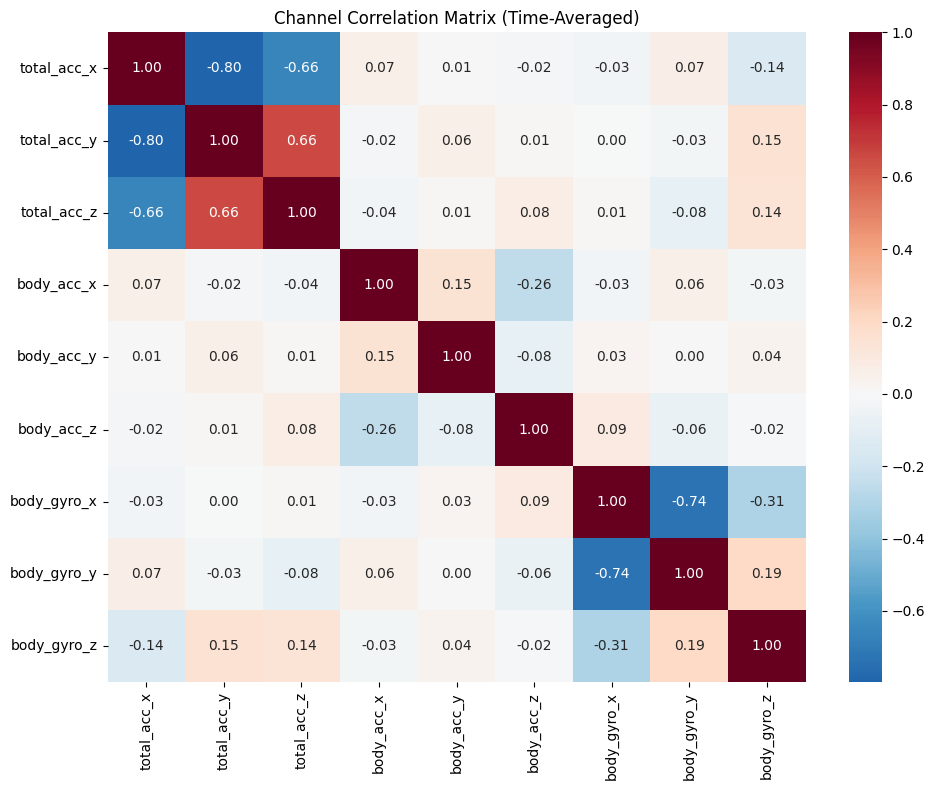


=== Static vs Dynamic Activities ===
Static activity windows: 4067
Dynamic activity windows: 3285
Average temporal std - Static: 0.0161
Average temporal std - Dynamic: 0.2862
Dynamic/Static ratio: 17.81


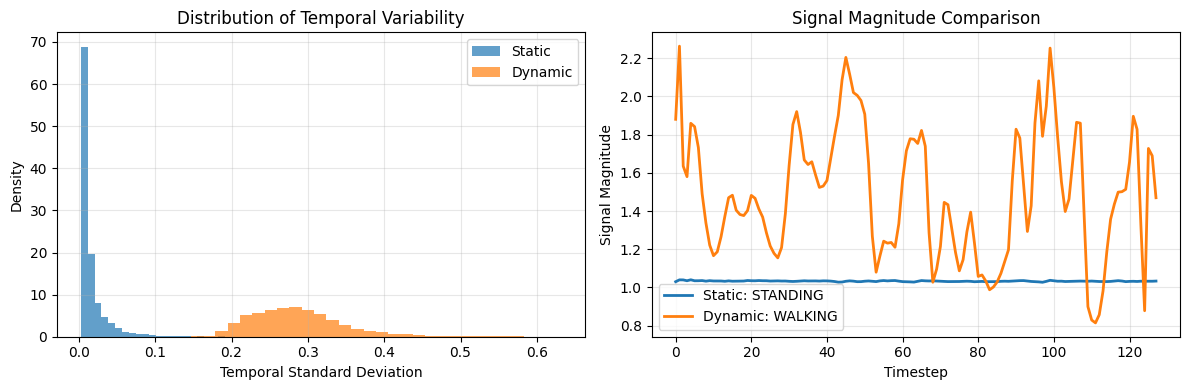

In [ ]:
# Channel statistics and correlation analysis
print("=== Channel Statistics ===")
channel_means = X_train.mean(axis=(0, 1))  # Mean across windows and timesteps
channel_stds = X_train.std(axis=(0, 1))

stats_df = pd.DataFrame({
    'Channel': data_loader.CHANNEL_NAMES,
    'Mean': channel_means,
    'Std': channel_stds
})
print(stats_df.round(4))

# Correlation between channels (averaged across time)
print("\n=== Channel Correlations ===")
# Average each window across time, then compute correlation
X_averaged = X_train.mean(axis=1)  # Shape: (n_windows, 9)
corr_matrix = np.corrcoef(X_averaged.T)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            xticklabels=data_loader.CHANNEL_NAMES,
            yticklabels=data_loader.CHANNEL_NAMES,
            annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Channel Correlation Matrix (Time-Averaged)')
plt.tight_layout()
plt.show()

# Static vs Dynamic activity comparison
print("\n=== Static vs Dynamic Activities ===")
static_activities = [4, 5, 6]  # SITTING, STANDING, LAYING
dynamic_activities = [1, 2, 3]  # WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS

static_mask = np.isin(y_train, static_activities)
dynamic_mask = np.isin(y_train, dynamic_activities)

print(f"Static activity windows: {static_mask.sum()}")
print(f"Dynamic activity windows: {dynamic_mask.sum()}")

# Compute temporal variability (std across time dimension)
static_temporal_std = X_train[static_mask].std(axis=1).mean()  # Std across time, then mean
dynamic_temporal_std = X_train[dynamic_mask].std(axis=1).mean()

print(f"Average temporal std - Static: {static_temporal_std:.4f}")
print(f"Average temporal std - Dynamic: {dynamic_temporal_std:.4f}")
print(f"Dynamic/Static ratio: {dynamic_temporal_std/static_temporal_std:.2f}")

# Show distribution of temporal std values for anomaly detection insight
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
static_stds = X_train[static_mask].std(axis=1).mean(axis=1)  # Std per window
dynamic_stds = X_train[dynamic_mask].std(axis=1).mean(axis=1)

plt.hist(static_stds, alpha=0.7, label='Static', bins=30, density=True)
plt.hist(dynamic_stds, alpha=0.7, label='Dynamic', bins=30, density=True)
plt.xlabel('Temporal Standard Deviation')
plt.ylabel('Density')
plt.title('Distribution of Temporal Variability')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Plot signal magnitude for first window of each type
static_idx = np.where(static_mask)[0][0]
dynamic_idx = np.where(dynamic_mask)[0][0]

# Compute signal magnitude (L2 norm across channels)
static_mag = np.linalg.norm(X_train[static_idx], axis=1)
dynamic_mag = np.linalg.norm(X_train[dynamic_idx], axis=1)

plt.plot(static_mag, label=f'Static: {activity_labels[y_train[static_idx]]}', linewidth=2)
plt.plot(dynamic_mag, label=f'Dynamic: {activity_labels[y_train[dynamic_idx]]}', linewidth=2)
plt.xlabel('Timestep')
plt.ylabel('Signal Magnitude')
plt.title('Signal Magnitude Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()